In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
iris=load_iris()

In [4]:
X=iris.data

y=iris.target

In [5]:
X.shape

(150, 4)

<Axes: >

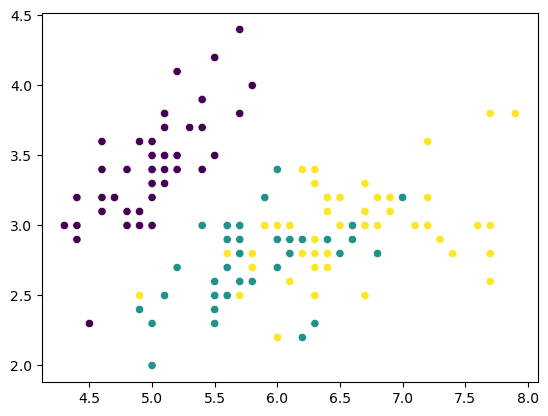

In [30]:
# Visulize data
sns.scatterplot(
    x=X[:,0],
    y=X[:,1],
    c=y
)

In [12]:
# Scaling data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [20]:
# Optimal - dimentionality reduction using PCA
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

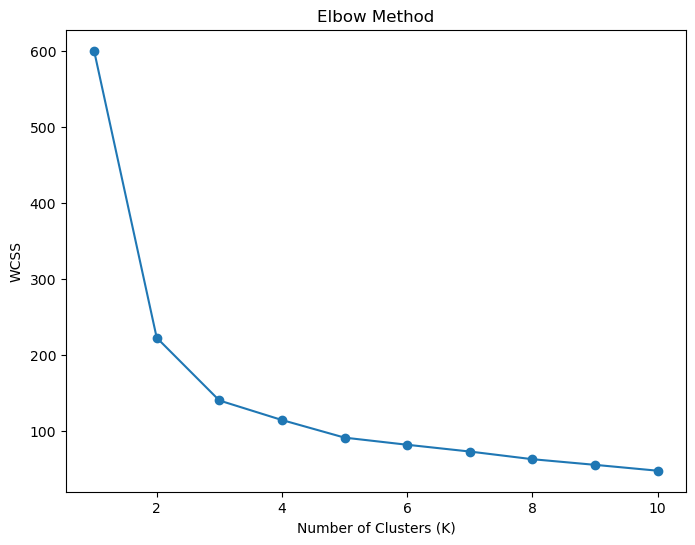

In [18]:
# Ellbow Method
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,   # for reproducibility
        n_init=10          # important for stability
    )
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

<Axes: >

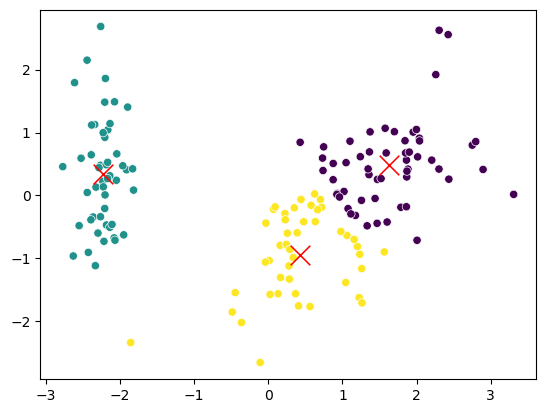

In [29]:
# Kmeans

kmeans=KMeans(n_clusters=3,random_state=10)
labels=kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="x",c="red",s=200)